# Inference with the Fine-Tuned YOLO Model

This notebook runs prediction with the best checkpoint produced by `train.py` / `train_resume.py` on the **test split** of `aod_dataset`.

What it covers:
- Load the fine-tuned `best.pt` from `runs/detect/runs/aod_big_run_2/weights/`
- Predict on a single test image and display the result
- Predict on a random batch of test images and show a grid
- Predict on the entire `aod_dataset/images/test` split, saving annotated outputs to disk
- Report key test-set metrics: mAP@50, mAP@50-95, precision, recall, and per-class breakdown

Classes: `aeroplane (0)`, `bird (1)`, `drone (2)`, `helicopter (3)`.

In [1]:
import os
import random
import shutil
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt

# MPS fallback for Apple Silicon (matches train.py)
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

from ultralytics import YOLO

In [2]:
# --- Paths ---
PROJECT_ROOT = Path.cwd()
MODEL_PATH = PROJECT_ROOT / "runs" / "detect" / "runs" / "aod_big_run_2" / "weights" / "best.pt"
TEST_IMAGES_DIR = PROJECT_ROOT / "aod_dataset" / "images" / "test"
DATA_YAML = PROJECT_ROOT / "data.yaml"

assert MODEL_PATH.exists(), f"Model not found at {MODEL_PATH}"
assert TEST_IMAGES_DIR.exists(), f"Test images not found at {TEST_IMAGES_DIR}"

# --- Model + class metadata ---
model = YOLO(str(MODEL_PATH))
class_names = {0: "aeroplane", 1: "bird", 2: "drone", 3: "helicopter"}

# Same color palette as video_object_tracking.ipynb
class_colors = {
    0: (255, 100, 0),    # aeroplane — blue
    1: (0, 255, 100),    # bird — green
    2: (0, 0, 255),      # drone — red
    3: (0, 255, 255),    # helicopter — yellow
}

# --- Inference defaults ---
IMG_SIZE = 640
CONF_THRESH = 0.25
IOU_THRESH = 0.45
DEVICE = "mps"  # change to "cpu" or 0 (CUDA index) if needed

print(f"Loaded model: {MODEL_PATH.name}")
print(f"Model classes: {model.names}")
print(f"Test images : {len(list(TEST_IMAGES_DIR.glob('*.jpg')))} files")

Loaded model: best.pt
Model classes: {0: 'aeroplane', 1: 'bird', 2: 'drone', 3: 'helicopter'}
Test images : 2241 files


## 1. Predict on a single test image

Quick sanity check on one image. The annotated frame is rendered with Ultralytics' built-in `plot()` and shown via matplotlib (BGR → RGB conversion).

Predicting on: yt-LjDxXdqh02s-0021_jpg.rf.d41efb99e40882bd83fa9b27e317440d.jpg
No detections.


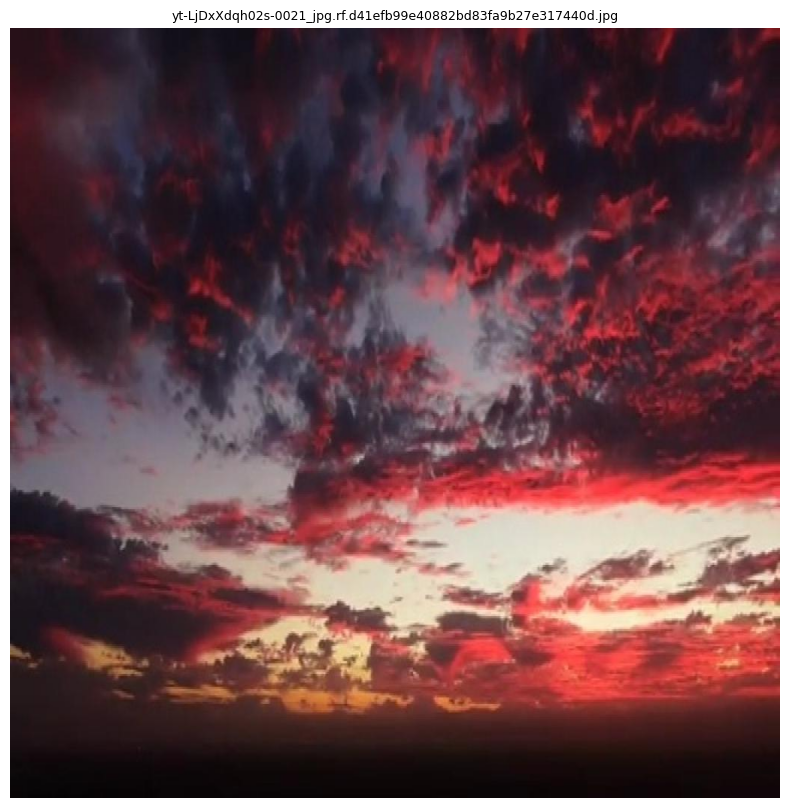

In [3]:
# Pick one image (deterministic seed so the demo is reproducible)
random.seed(0)
all_test_images = sorted(TEST_IMAGES_DIR.glob("*.jpg"))
sample_image = random.choice(all_test_images)
print(f"Predicting on: {sample_image.name}")

results = model.predict(
    source=str(sample_image),
    imgsz=IMG_SIZE,
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    device=DEVICE,
    verbose=False,
)

result = results[0]
annotated_bgr = result.plot()  # numpy array, BGR
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

# Print a quick summary of detections
if result.boxes is not None and len(result.boxes) > 0:
    cls_ids = result.boxes.cls.int().tolist()
    confs = result.boxes.conf.tolist()
    counts = Counter(cls_ids)
    print(f"Detections: {len(cls_ids)}")
    for cid, n in sorted(counts.items()):
        print(f"  {class_names[cid]:11s}: {n}")
    print(f"  conf range : {min(confs):.2f} – {max(confs):.2f}")
else:
    print("No detections.")

plt.figure(figsize=(10, 10))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title(sample_image.name, fontsize=9)
plt.show()

## 2. Predict on a random batch — grid view

Running inference on a handful of test images at once and displaying them in a grid gives a quick qualitative read of model behaviour across different scenes.

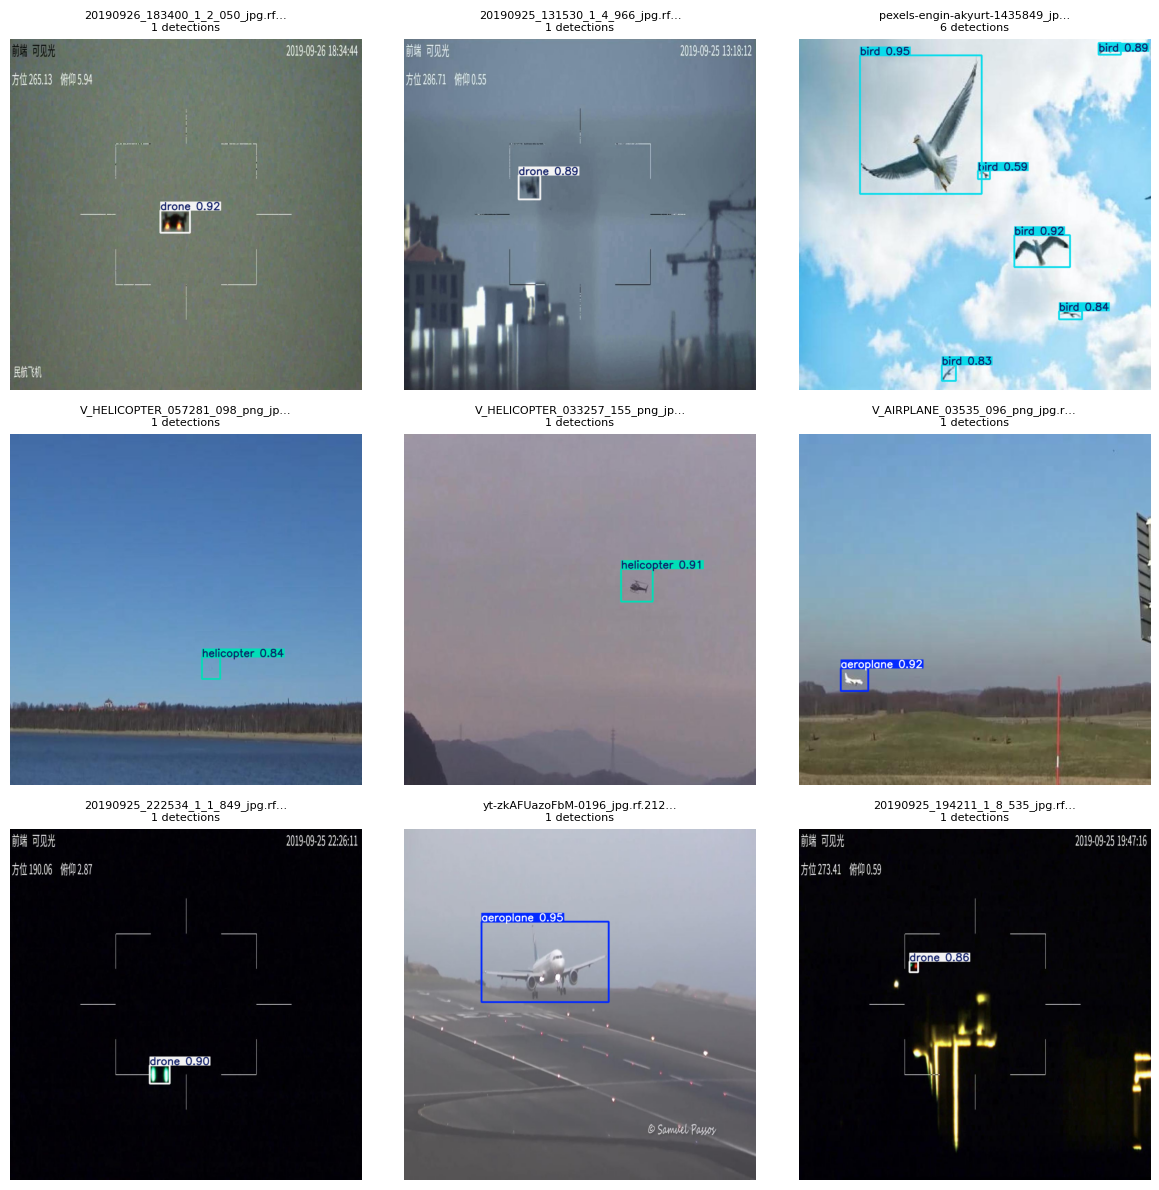

In [4]:
N_SAMPLES = 9  # 3x3 grid
GRID_COLS = 3

random.seed(42)
batch_paths = random.sample(all_test_images, N_SAMPLES)

# Ultralytics accepts a list of paths and batches internally
batch_results = model.predict(
    source=[str(p) for p in batch_paths],
    imgsz=IMG_SIZE,
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    device=DEVICE,
    verbose=False,
)

rows = (N_SAMPLES + GRID_COLS - 1) // GRID_COLS
fig, axes = plt.subplots(rows, GRID_COLS, figsize=(4 * GRID_COLS, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, path, res in zip(axes, batch_paths, batch_results):
    img_rgb = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
    n_det = 0 if res.boxes is None else len(res.boxes)
    ax.imshow(img_rgb)
    ax.set_title(f"{path.name[:30]}…\n{n_det} detections", fontsize=8)
    ax.axis("off")

# Hide any unused subplots (when N_SAMPLES isn't a clean multiple of GRID_COLS)
for ax in axes[len(batch_paths):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Predict on the full test split — save annotated images to disk

Ultralytics streams results so this is memory-friendly even for the full 2k+ image test set.

Annotated images are written to `test_split_prediction/` at the project root. The folder is **wiped clean before each run** so you never end up with stale files from a previous prediction (different image set, different confidence threshold, etc.) mixed into the new output.

In [5]:
PREDICT_DIR = PROJECT_ROOT / "test_split_prediction"

# Wipe any previous run so we never mix stale files from earlier predictions
if PREDICT_DIR.exists():
    shutil.rmtree(PREDICT_DIR)
    print(f"Cleared previous output at: {PREDICT_DIR}")
PREDICT_DIR.mkdir(parents=True, exist_ok=True)

# `stream=True` returns a generator — we iterate to keep memory bounded
stream = model.predict(
    source=str(TEST_IMAGES_DIR),
    imgsz=IMG_SIZE,
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    device=DEVICE,
    save=True,           # write annotated images
    save_txt=False,      # set True to also dump YOLO-format label files
    save_conf=False,     # set True to include confidences in saved labels
    project=str(PROJECT_ROOT),     # parent folder
    name=PREDICT_DIR.name,         # leaf folder → <root>/test_split_prediction
    exist_ok=True,                 # we already cleaned it; just allow writes
    stream=True,
    verbose=False,
)

total_images = 0
total_detections = 0
class_totals = Counter()
images_with_detections = 0

for res in stream:
    total_images += 1
    if res.boxes is not None and len(res.boxes) > 0:
        cls_ids = res.boxes.cls.int().tolist()
        total_detections += len(cls_ids)
        class_totals.update(cls_ids)
        images_with_detections += 1

    if total_images % 250 == 0:
        print(f"  processed {total_images} images …")

print("\n=== Test-set inference summary ===")
print(f"Images processed       : {total_images}")
print(f"Images with detections : {images_with_detections} "
      f"({100 * images_with_detections / max(total_images, 1):.1f}%)")
print(f"Total detections       : {total_detections}")
for cid in sorted(class_names.keys()):
    print(f"  {class_names[cid]:11s}: {class_totals.get(cid, 0)}")
print(f"\nAnnotated images saved to: {PREDICT_DIR}")

  processed 250 images …
  processed 500 images …
  processed 750 images …
  processed 1000 images …
  processed 1250 images …
  processed 1500 images …
  processed 1750 images …
  processed 2000 images …
Results saved to /Users/mldevpilot/prj_ws/my_git_hub_repos/Realtime-Airborne-Object-Detection-and-Tracking/test_split_prediction

=== Test-set inference summary ===
Images processed       : 2241
Images with detections : 2169 (96.8%)
Total detections       : 3274
  aeroplane  : 781
  bird       : 835
  drone      : 832
  helicopter : 826

Annotated images saved to: /Users/mldevpilot/prj_ws/my_git_hub_repos/Realtime-Airborne-Object-Detection-and-Tracking/test_split_prediction


## 4. Test-set performance metrics

Quantitative read on how the model does on the held-out test split. We use `model.val(split="test", ...)` because that's the Ultralytics API that compares predictions against ground-truth labels and computes mAP / precision / recall. Despite the method name, this is **evaluation on the test split**, not on val.

Outputs land in `test_split_metrics/` at the project root (PR curves, confusion matrix, F1 curves). The folder is **wiped clean before each run** for the same reason as `test_split_prediction/` — no stale artefacts from previous evaluations.

Key metrics shown below:
- **mAP@50** — mean Average Precision at IoU 0.50 (loose match)
- **mAP@50-95** — averaged across IoU thresholds 0.50:0.05:0.95 (the standard COCO metric, stricter)
- **Precision / Recall** — at the model's default operating point
- **Per-class breakdown** — to spot where the model is strong vs. weak

In [6]:
METRICS_DIR = PROJECT_ROOT / "test_split_metrics"

# Wipe any previous evaluation artefacts so we don't mix old/new plots
if METRICS_DIR.exists():
    shutil.rmtree(METRICS_DIR)
    print(f"Cleared previous metrics at: {METRICS_DIR}")

test_metrics = model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=IMG_SIZE,
    conf=0.001,                    # standard low conf for mAP computation
    iou=0.6,                       # standard IoU for NMS during evaluation
    device=DEVICE,
    project=str(PROJECT_ROOT),     # parent folder
    name=METRICS_DIR.name,         # leaf folder → <root>/test_split_metrics
    exist_ok=True,
    plots=True,                    # save PR / F1 curves and confusion matrix
    verbose=False,
)

box = test_metrics.box

# Stash the headline scalars so we can compare against the baseline later
finetuned_scores = {
    "mAP@50":     float(box.map50),
    "mAP@50-95":  float(box.map),
    "Precision":  float(box.mp),
    "Recall":     float(box.mr),
}

print("=" * 50)
print("  TEST-SET PERFORMANCE — fine-tuned YOLO")
print("=" * 50)
for k, v in finetuned_scores.items():
    print(f"  {k:<11s}: {v:.4f}")
print("=" * 50)

# Per-class table
print(f"\n{'Class':<12} {'P':>8} {'R':>8} {'mAP50':>8} {'mAP50-95':>10}")
print("-" * 50)
for i, cid in enumerate(box.ap_class_index.astype(int).tolist()):
    name = class_names.get(cid, str(cid))
    p   = float(box.p[i])
    r   = float(box.r[i])
    m50 = float(box.ap50[i])
    m   = float(box.ap[i].mean()) if hasattr(box.ap[i], 'mean') else float(box.ap[i])
    print(f"{name:<12} {p:>8.4f} {r:>8.4f} {m50:>8.4f} {m:>10.4f}")

print(f"\nFull report saved to: {METRICS_DIR}")

Ultralytics 8.4.33 🚀 Python-3.11.15 torch-2.11.0 MPS (Apple M1 Pro)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 154.3±19.6 MB/s, size: 37.6 KB)
val: Scanning /Users/mldevpilot/prj_ws/my_git_hub_repos/Realtime-Airborne-Object-Detection-and-Tracking/aod_dataset/labels/test.cache... 2241 images, 56 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2241/2241 552.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 141/141 1.7it/s 1:220.5sss
                   all       2241       3171      0.956      0.941      0.974      0.715
Speed: 0.2ms preprocess, 16.2ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /Users/mldevpilot/prj_ws/my_git_hub_repos/Realtime-Airborne-Object-Detection-and-Tracking/test_split_metrics
  TEST-SET PERFORMANCE — fine-tuned YOLO
  mAP@50     : 0.9740
  mAP@50-95  : 0.7152
  Precision  : 0.9559
  Recall     : 0.9413

Class               P        R    mAP50   mAP50-95
---------------

## Notes

- Adjust `CONF_THRESH` to trade off recall vs. precision when generating annotated outputs. `0.25` is the Ultralytics default.
- For CPU inference change `DEVICE = "cpu"`; for an NVIDIA GPU use `DEVICE = 0`.
- To also dump per-image YOLO label files alongside the annotated images, flip `save_txt=True` (and `save_conf=True` to include confidence) in step 3.
- Both `test_split_prediction/` and `test_split_metrics/` are wiped at the start of their respective cells, so re-running is always clean.